

1. Implement a reinforcement learning control approach which the robot uses to determine
optimum actions, based on rewards and penalties received by the environment. The Qlearning algorithm will be used.
2. Implement a neural network approach which controls the robot and determines its next
action. Python and the sklearn library will be used.
3. Implement the reinforcement learning control approach for different mazes which are defined and read in a file.
4. Write a short report (no more than 5 pages) discussing your results with the inclusion of
appropriate diagrams.

## The Problem:

It is highly desirable to have robots which are able to adapt and operate in unknown or changing
environments and circumstances which they have not encountered before.

Here, we consider a mobile robot which navigates an unknown environment, trying to find the
optimum path to a goal location while avoiding collisions with the obstacles. The environment
is a maze shown in Figure 1. A black square represents a location where there is an obstacle
and the robot cannot move to such a cell.

At every time step $t$, the available actions for the robot are: move north (North action),
move east (East action), move south (South action) or move west (West action).
The starting and the target (goal) positions of the robot could be any square in the maze
which is not occupied by an obstacle. The robot’s task is based on the current position and a
pre-specified end position (the goal): to take a optimum action at time step $t$ so that the time
required (number of steps) to reach the destination (target) is minimised.
The number of combinations of all possible inputs, i.e. (starting position, target goal position) is (28 × 27 = 756).

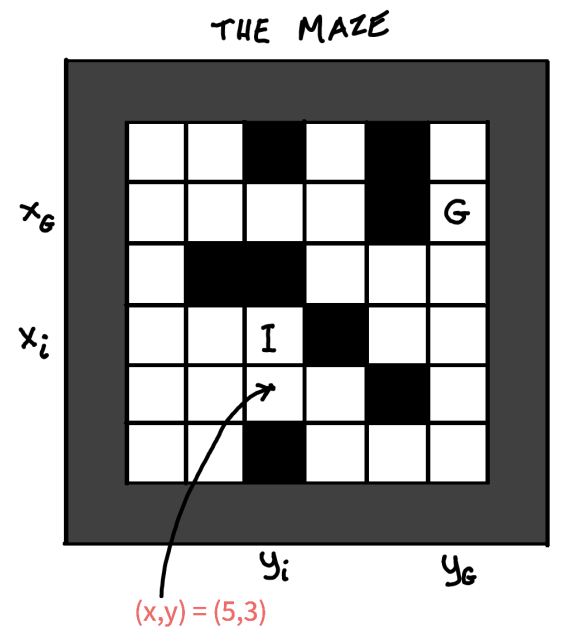

Figure 1: The maze environment for the robot for tasks 1 and 2. $I$ is the initial position of
the robot with coordinates ($x_i$
, $y_i$). $G$ is the target (goal) position of the robot with coordinates
($x_G$, $y_G$).

# Part 1: Reinforcement Learning Control of the Robot

## 1.1
Starting with implementing the Q-learning control algorithm from module, from scratch. WITHOUT using libraries to implement algo. As per cw instructions. (see MobileRobotControl_Robotics_draftCODEblock_w1905050.ipynb file.)


## 1.2 - Task 1 CODE
Including generating data for all goals + main execution


In [1]:
from os import path
import numpy as np
import random
#define maze environment

class MazeEnvironment:
  def __init__(self):
    # 0 is empty, 1 is obstacle
    self.rows = 6
    self.cols = 6
    self.grid = np.array([
        [0, 0, 1, 0, 1, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 1, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0, 0]
    ])

    # key of actions: 0 is north, 1 is east, 2 is south, 3 is west
    self.actions =  [0,1,2,3]
    self.action_names = {0: 'N', 1: 'E', 2: 'S', 3: 'W'}
  def is_valid(self, r, c):
    # to check if a coordinate is within bounds and NOT an obstacle
    if 0 <= r < self.rows and 0 <= c < self.cols:
      if self.grid[r, c] == 0:
        return True
      return False
  def get_valid_cells(self):
    # to return a list of all coordinates (r,c) that are NOT obstacles
    cells = []
    for r in range(self.rows):
      for c in range(self.cols):
        if self.grid[r, c] == 0:
          cells.append((r, c))
    return cells
  def step(self,state,action):
    #apply action to state (r,c), returns next_state.
    #if hit wall or obstacle, it stays in the same cell!
    r,c = state
    #calculate possible new coordinates
    if action == 0: # north
      nr, nc = r - 1, c
    elif action == 1: #east
      nr, nc = r, c + 1
    elif action == 2: #south
      nr, nc = r + 1, c
    elif action == 3: #west
      nr, nc = r, c - 1
    else:
      return state

    #checking validity
    if self.is_valid(nr, nc):
      return (nr, nc)
    else:
      return state #stay same
# implementing q-learning

def run_q_learning(env, goal_pos, gamma=0.9, episodes=2000):
  # running q-learning for a speciic goal position
  #based on the update rule: Q(s,a)=r+gamma*max(Q(s',a'))

  #intialise q-table
  # numpy array Q[row, col, action]
  Q = np.zeros((env.rows, env.cols, 4))

  valid_cells = env.get_valid_cells()

  for e in range(episodes):
    #starting from random valid position
    start_idx = random.randint(0, len(valid_cells) - 1)
    current_state = valid_cells[start_idx]

    #loop until goal reached (limit has been set to 1000 to avoid infinite loops!)
    steps = 0
    while current_state != goal_pos and steps < 1000:
      r,c = current_state
      action = random.choice(env.actions)
      next_state = env.step(current_state, action)
      nr, nc = next_state

      #give reward
      if next_state == goal_pos:
        reward = 100
      else:
        reward = 0
      #updating q-value
      max_q_next = np.max(Q[nr, nc, :])
      Q[r, c, action] = reward + gamma * max_q_next
      #move to next
      current_state = next_state
      steps += 1
  return Q

def generate_full_dataset(env):
  #iterating through all valid cells as potential goal, to learn the optimal
  # q-table for the goal. extract best action
  valid_cells = env.get_valid_cells()
  dataset = []

  print(f"Generating CLEAN dataset for {len(valid_cells)} possible goal positions . . .")

  for goal in valid_cells:
    Q_table = run_q_learning(env, goal, gamma=0.9,episodes=2000)
    for start in valid_cells:
      if start == goal:
        continue
      sx, sy = start
      gx, gy = goal

      #action with highest q-value ADDING IF statement for better filtering as robot gets stuck
      if np.max(Q_table[sx, sy, :]) != 0:
        best_action = np.argmax(Q_table[sx, sy, :])
        dataset.append({
            'input': [sx, sy, gx, gy],
            'target': best_action
        })
  print(f"Dataset generation is done. Total samples: {len(dataset)}")
  return dataset

#main

if __name__ == "__main__":
    #initialising env
    maze = MazeEnvironment()
    print(f"Maze initialised. Number of free cells: {len(maze.get_valid_cells())}")

    # defining I and G from figure
    start_pos_I = (3,2) #xi,yi = (4, 3) row 4, col 3
    goal_pos_G = (1,5) #xg,yg = (2,6) row 2, col 6

    print(f"Task 1 config : start at I: {start_pos_I}, goal at G: {goal_pos_G}")

    #generate dataset for all possible start/goal combos
    training_data = generate_full_dataset(maze)

    print("\n--- Solving I ---> G ---")

    #run q-learning for the fixed goal G
    Q_check = run_q_learning(maze, goal_pos_G, gamma=0.9, episodes=2000)

    curr = start_pos_I
    path = [curr]
    print(f"Tracing path from {curr} to {goal_pos_G} . . .")

    for _ in range(20):
      if curr == goal_pos_G:
        break
      r,c = curr
      #using learned q-table
      action = np.argmax(Q_check[r,c, :])
      curr = maze.step(curr, action)
      path.append(curr)

    print(f"Path taken: {path}")
    if path[-1] == goal_pos_G:
      print("Result: Success! Goal has been reached !!")
    else:
      print("Result: Failure... Goal was not reached ...")

    #saving for next task
    X_all = np.array([d['input'] for d in training_data])
    y_all = np.array([d['target'] for d in training_data])
    print(f" X Shape: {X_all.shape}, y Shape: {y_all.shape}")

Maze initialised. Number of free cells: 28
Task 1 config : start at I: (3, 2), goal at G: (1, 5)
Generating CLEAN dataset for 28 possible goal positions . . .
Dataset generation is done. Total samples: 756

--- Solving I ---> G ---
Tracing path from (3, 2) to (1, 5) . . .
Path taken: [(3, 2), (4, 2), (4, 3), (5, 3), (5, 4), (5, 5), (4, 5), (3, 5), (2, 5), (1, 5)]
Result: Success! Goal has been reached !!
 X Shape: (756, 4), y Shape: (756,)


# Part 2: Neural network control of the robot

## 2.1 - CODE
& report material

- Learn optimal robot actions using Q-learning
- Convert Q-learning outputs into a supervised dataset
- Train an MLP neural network to imitate the learned policy
- Evaluate generalisation on unseen robot–goal configurations


--- Beginning Task 2: Neural Network Training ---
Training samples: 604
Testing samples: 152

Training Neural Network . . . 
Getting Training Accuracy . . . 
Training Accuracy: 82.95%

Evaluating Neural Network . . . 

Model Accuracy on Test Set: 78.29%


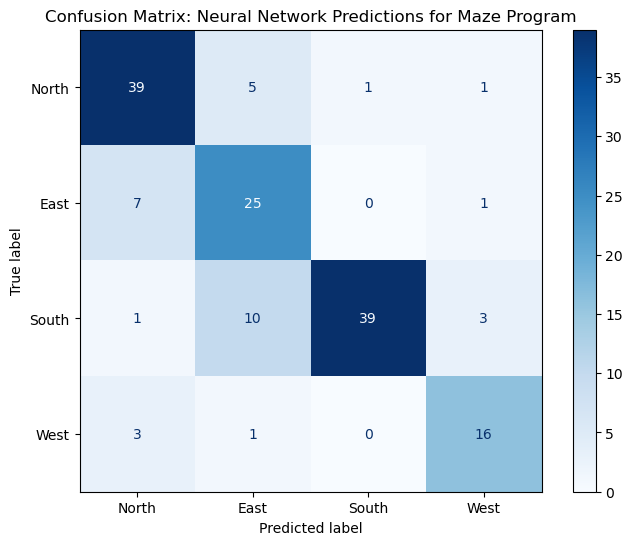


Classification Report:
              precision    recall  f1-score   support

       North       0.78      0.85      0.81        46
        East       0.61      0.76      0.68        33
       South       0.97      0.74      0.84        53
        West       0.76      0.80      0.78        20

    accuracy                           0.78       152
   macro avg       0.78      0.79      0.78       152
weighted avg       0.81      0.78      0.79       152



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
#some code is adapted from 
#Lecture 8: Robot Control - Intelligent Control Algorithms, Dracopoulos (2025)
# using arrays from task 1, X_all and y_all

print("\n--- Beginning Task 2: Neural Network Training ---")

#splitting data into training (80%) and testing (20%) + setting random state
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

#initialising and taining the neural network, adding hidden layers
mlp = MLPClassifier(
    activation='relu',
    hidden_layer_sizes=(100,100), #increased size from first test
    alpha=0.001,
    max_iter=10000, #following lecture example, this had been a typo to only 1000 in the original test
    random_state=42,
    early_stopping=False
)

print("\nTraining Neural Network . . . ")
mlp.fit(X_train, y_train)

train_acc = mlp.score(X_train, y_train)
print("Getting Training Accuracy . . . ")

print(f"Training Accuracy: {train_acc * 100:.2f}%")

# evaluating the model
print("\nEvaluating Neural Network . . . ")

y_pred = mlp.predict(X_test)

# calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")

#metrics and diagrams for report (task4)
#confusion matrix

cm = confusion_matrix(y_test, y_pred)
labels = ['North', 'East', 'South', 'West']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix: Neural Network Predictions for Maze Program')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['North', 'East', 'South', 'West']))



In [3]:
# testing robot on the specific path (I--->G)

print("\n--- Testing Neural Network Robot on I ---> G Path ---")

#coordinates given
start_pos = (3,2)
goal_pos = (1,5)

curr = start_pos
nn_path = [curr]
max_steps = 20

print(f"Neural Network Path from {curr} to {goal_pos} . . .")

for _ in range(max_steps):
  if curr == goal_pos:
    break
  # NN: [current_r, current_c, goal_r, goal_c]
  input_vector = np.array([[curr[0], curr[1], goal_pos[0], goal_pos[1]]])

  action = mlp.predict(input_vector)[0]

  curr = maze.step(curr, action)
  nn_path.append(curr)

print(f"Path taken by NN (neural network): {nn_path}")

if nn_path[-1] == goal_pos:
      print("Success! The Neural Network has successfully navigated to the goal!")
else:
      print("Failure ... Unfortunately, the Neural Network has failed to reach the goal...")


--- Testing Neural Network Robot on I ---> G Path ---
Neural Network Path from (3, 2) to (1, 5) . . .
Path taken by NN (neural network): [(3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2), (3, 2)]
Failure ... Unfortunately, the Neural Network has failed to reach the goal...


# Part 3: Reinforcement Learning for different mazes


## 3.1
Reading maze config from text file and applying what was done for part 1.
- Created the input text file named 'maze_config.txt'

In [7]:
import numpy as np
import random

class FileMazeEnvironment:
  def __init__(self, filename):
    self.filename = filename
    self.grid = None
    self.rows = 0
    self.cols = 0
    self.start_pos = (0,0)
    self.goal_pos = (0,0)
    self.actions = [0, 1, 2, 3] # north, east, south, west
    self.action_names = {0: 'N', 1: 'E', 2: 'S', 3: 'W'}

    self.load_maze()
  def load_maze(self):
    print(f"Reading maze from {self.filename} . . . please stand by ... ")
    with open(self.filename, 'r') as f:
      lines = [line.strip() for line in f.readlines() if line.strip()]

    #getting dimensions, line 1
    dims = lines[0].split()
    self.rows = int(dims[0])
    self.cols = int(dims[1])
    #start position , line 2
    start_raw = lines[1].split()
    self.start_pos = (int(start_raw[0])-1, int(start_raw[1])-1)
    #goal pos, line 3
    goal_raw = lines[2].split()
    self.goal_pos = (int(goal_raw[0])-1, int(goal_raw[1])-1)

    #the rest of the txt files has the grid for the maze and as usual,
    # 0 is empty, 1 is obstacle
    grid_lines = lines[3:]
    self.grid = np.zeros((self.rows, self.cols), dtype=int)

    for r, line in enumerate(grid_lines):
      vals = [int(ch) for ch in line if ch in ['0', '1']]
      if len(vals) != self.cols:
        print(f"Row {r + 1} has an incorrect number of columns.")
      self.grid[r, :] = vals[:self.cols]
    print("Maze loaded successfully!")
    print(f"Maze dimensions: {self.rows}x{self.cols}")
    print(f"Start position: {self.start_pos}")
    print(f"Goal position: {self.goal_pos}")
  #same as task 1
  def is_valid(self, r, c):
    if 0 <= r < self.rows and 0 <= c < self.cols:
      if self.grid[r, c] == 0:
        return True
    return False
  def get_valid_cells(self):
    return [(r, c) for r in range(self.rows) for c in range(self.cols) if self.grid[r, c] == 0]
  def step(self,state,action):
    r, c = state
    if action == 0: nr, nc = r -1, c
    elif action == 1: nr, nc = r, c + 1
    elif action == 2: nr, nc = r + 1, c
    elif action == 3: nr, nc = r, c - 1
    else: return state

    if self.is_valid(nr, nc): return (nr, nc)
    return state

#reusing q-learning function from part 1
def run_q_learning(env, goal_pos, gamma=0.9, episodes=2000):
  Q= np.zeros((env.rows, env.cols, 4))
  valid_cells = env.get_valid_cells()

  for e in range(episodes):
    start_idx = random.randint(0, len(valid_cells)-1)
    curr = valid_cells[start_idx]
    steps = 0
    while curr != goal_pos and steps < 1000:
      r, c = curr
      action = random.choice(env.actions)
      next_s = env.step(curr, action)
      nr, nc = next_s

      reward = 100 if next_s == goal_pos else 0

      max_q = np.max(Q[nr, nc, :])
      Q[r, c, action] = reward + gamma * max_q

      curr = next_s
      steps += 1
  return Q

#main

if __name__ == "__main__":
  #(1)initialising env, getting txt must be in folder!!
  try:
    # here, path must be specific to maze_config.txt file or other maze files
    # edit as needed! so... 
    #maze 1 : maze_config.txt, maze 2: maze_2.txt, maze 3: maze_3.txt
    #env = FileMazeEnvironment('maze_config.txt')
    #env = FileMazeEnvironment('maze_2.txt')
    env = FileMazeEnvironment('maze_3.txt')
      
    #(2)running q-learning for specified goal from txt
    print("\nRunning Q-Learning on File Maze . . .")
    Q_table = run_q_learning(env, env.goal_pos, episodes=3000)

    #(3) testing the result
    curr = env.start_pos
    path = [curr]

    print(f"Tracing path from {curr} to {env.goal_pos}. . . ")
    for _ in range(30):
      if curr == env.goal_pos: break

      action = np.argmax(Q_table[curr[0], curr[1], :])
      curr = env.step(curr, action)
      path.append(curr)

    print(f"Path: {path}")
    if path[-1] == env.goal_pos:
      print("Success! The maze provided by the txt file has been solved!")
    else:
      print("Failure... unfortunately, the maze provided was not solved...")
  except FileNotFoundError:
    print("Sorry, please make a 'maze_config.txt' first!")

Reading maze from maze_3.txt . . . please stand by ... 
Maze loaded successfully!
Maze dimensions: 10x10
Start position: (0, 0)
Goal position: (3, 8)

Running Q-Learning on File Maze . . .
Tracing path from (0, 0) to (3, 8). . . 
Path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (2, 5), (2, 6), (1, 6), (0, 6), (0, 7), (0, 8), (0, 9), (1, 9), (2, 9), (3, 9), (3, 8)]
Success! The maze provided by the txt file has been solved!
